# Autoenkodery

### Zakres ćwiczeń
Autoenkodery - specyficzna klasa sieci, których charakterystyczną właściwością jest zdolność do znajdowania wąskich reprezentacji danych

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
import keras
import matplotlib.pyplot as plt


### Przygotowanie zbioru danych

In [ ]:
dataset = tf.keras.datasets.mnist.load_data()
(X_train_full, y_train_full), (X_test, y_test) = dataset
X_train_full = X_train_full.astype(np.float32) / 255
X_test = X_test.astype(np.float32) /255
X_train, X_valid = X_train_full[:-5000], X_train_full[-5000:]
y_train, y_valid = y_train_full[:-5000], y_train_full[-5000:]

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


### Autoenkoder z warstwami gęstymi

In [ ]:
encoder = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=[28,28]),
    tf.keras.layers.Dense(100, activation='selu'),
    tf.keras.layers.Dense(30, activation='selu')
])

decoder = tf.keras.Sequential([
    tf.keras.layers.Dense(100, activation='selu', input_shape=[30]),
    tf.keras.layers.Dense(28*28, activation='sigmoid'),
    keras.layers.Reshape([28, 28])
])

ae = tf.keras.Sequential([encoder, decoder])
ae.compile(loss='binary_crossentropy', optimizer='adam',metrics=['mae'])
history = ae.fit(X_train, X_train, epochs=5, validation_data=(X_valid, X_valid))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - loss: 0.1857 - mae: 0.0993 - val_loss: 0.1107 - val_mae: 0.0460
Epoch 2/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 18s 6ms/step - loss: 0.1082 - mae: 0.0445 - val_loss: 0.1033 - val_mae: 0.0409
Epoch 3/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 0.1012 - mae: 0.0397 - val_loss: 0.0991 - val_mae: 0.0381
Epoch 4/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - loss: 0.0976 - mae: 0.0372 - val_loss: 0.0962 - val_mae: 0.0360
Epoch 5/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - loss: 0.0949 - mae: 0.0353 - val_loss: 0.0942 - val_mae: 0.0344


In [ ]:
ae_stacked_mae = ae.evaluate(X_test, X_test, return_dict=True)
ae_stacked_mae

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0926 - mae: 0.0342


{'loss': 0.09232466667890549, 'mae': 0.03352902829647064}

In [ ]:
def plot_reconstructions(model, images=X_test, n_images=5):
  reconstructions = np.clip(model.predict(images[:n_images]), 0, 1)
  fig = plt.figure(figsize=(n_images * 1.5, 3))
  for image_index in range(n_images):
    plt.subplot(2, n_images, 1 + image_index)
    plt.imshow(images[image_index], cmap='binary')
    plt.axis('off')
    plt.subplot(2, n_images, 1 + n_images + image_index)
    plt.imshow(reconstructions[image_index], cmap='binary')
    plt.axis('off')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step


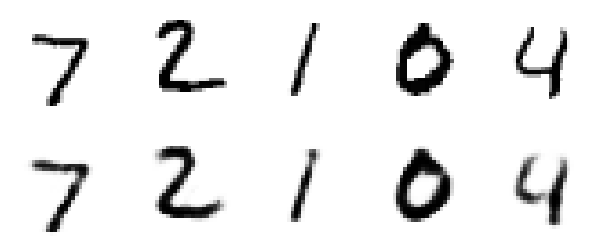

In [ ]:
plot_reconstructions(ae)

In [ ]:
# Zapisanie modelu
ae.save('ae_stacked.keras')

### Autoenkoder konwolucyjny

In [ ]:
# Enkoder strukturarozmiar map cech powinien się stopniowo zmniejszać przy jednoczesnym zwiększaniu liczby filtrów
conv_encoder = keras.models.Sequential([
keras.layers.Reshape([28, 28, 1], input_shape=[28, 28]),
keras.layers.Conv2D(16, kernel_size=3, padding="SAME",
activation="selu"),
keras.layers.MaxPool2D(pool_size=2),
keras.layers.Conv2D(32, kernel_size=3, padding="SAME",
activation="selu"),
keras.layers.MaxPool2D(pool_size=2),
keras.layers.Conv2D(64, kernel_size=3, padding="SAME",
activation="selu"),
keras.layers.MaxPool2D(pool_size=2)
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/reshape.py:39: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# W dekoderze odwrotna kolejność niż w enkoderze
conv_decoder = keras.models.Sequential([
keras.layers.Conv2DTranspose(32, kernel_size=3, strides=2,
padding="VALID", activation="selu",
input_shape=[3, 3, 64]),
keras.layers.Conv2DTranspose(16, kernel_size=3, strides=2,
padding="SAME", activation="selu"),
keras.layers.Conv2DTranspose(1, kernel_size=3, strides=2,
padding="SAME",
activation="sigmoid"),
keras.layers.Reshape([28, 28])
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv_transpose.py:94: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(


In [ ]:
conv_ae = tf.keras.Sequential([conv_encoder, conv_decoder])
conv_ae.compile(loss='binary_crossentropy', optimizer='adam',metrics=['mae'])
history_conv = conv_ae.fit(X_train, X_train, epochs=5, validation_data=(X_valid, X_valid))

Epoch 1/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 59s 33ms/step - loss: 0.1734 - mae: 0.0912 - val_loss: 0.0843 - val_mae: 0.0276
Epoch 2/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 81s 32ms/step - loss: 0.0816 - mae: 0.0259 - val_loss: 0.0775 - val_mae: 0.0225
Epoch 3/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 82s 32ms/step - loss: 0.0760 - mae: 0.0217 - val_loss: 0.0748 - val_mae: 0.0204
Epoch 4/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 83s 33ms/step - loss: 0.0732 - mae: 0.0194 - val_loss: 0.0725 - val_mae: 0.0186
Epoch 5/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 81s 32ms/step - loss: 0.0714 - mae: 0.0180 - val_loss: 0.0712 - val_mae: 0.0175


In [ ]:
print(conv_ae.evaluate(X_test, X_test, return_dict=True))

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 0.0694 - mae: 0.0170
{'loss': 0.06997700780630112, 'mae': 0.016972770914435387}


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step


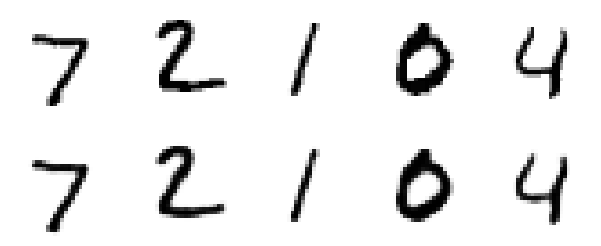

In [ ]:
plot_reconstructions(conv_ae)
plt.show()

In [ ]:
conv_ae.save('ae_conv.keras')

### Wizualizacja wyników
Gęste reprezentacje produkowane przez autoenkodery często wykorzystane są do wizualizacji danych

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


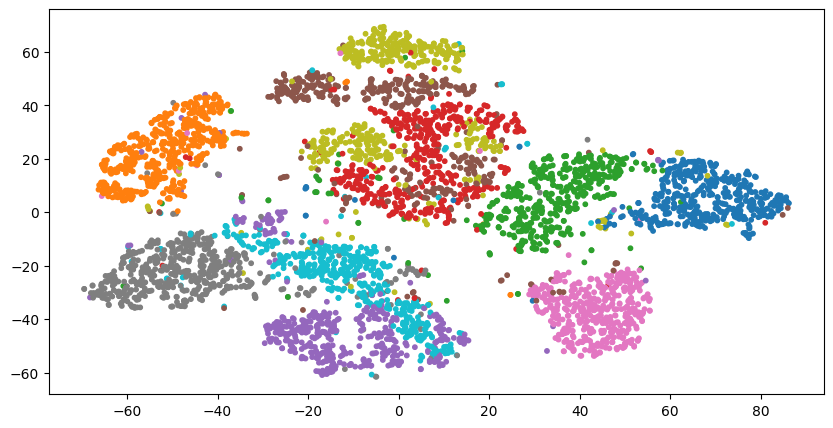

In [ ]:
from sklearn.manifold import TSNE

X_valid_compressed = conv_encoder.predict(X_valid)
X_valid_compressed = X_valid_compressed.reshape(len(X_valid_compressed), -1)
tsne = TSNE(init='pca', learning_rate='auto', random_state=42)
X_valid_2D = tsne.fit_transform(X_valid_compressed)

plt.figure(figsize=(10, 5))
plt.scatter(X_valid_2D[:, 0], X_valid_2D[:, 1], c=y_valid, s=10, cmap='tab10')
plt.show()

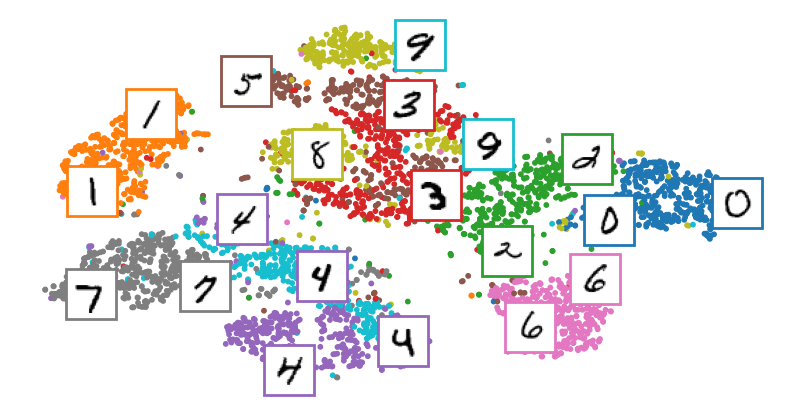

In [ ]:
import matplotlib as mpl
plt.figure(figsize=(10, 5))
cmap = plt.cm.tab10
Z = X_valid_2D
Z = (Z - Z.min()) / (Z.max() - Z.min()) # normalize to the 0-1 range
plt.scatter(Z[:, 0], Z[:, 1], c=y_valid, s=10, cmap=cmap)
image_positions = np.array([[1., 1.]])
for index, position in enumerate(Z):
  dist = ((position - image_positions) ** 2).sum(axis=1)
  if dist.min() > 0.02:
    image_positions = np.r_[image_positions, [position]]
    imagebox = mpl.offsetbox.AnnotationBbox(
      mpl.offsetbox.OffsetImage(X_valid[index], cmap="binary"),
      position, bboxprops={"edgecolor": cmap(y_valid[index]), "lw": 2})
    plt.gca().add_artist(imagebox)

plt.axis("off")
plt.show()

### Odszumianie

In [ ]:
dropout_encoder = keras.models.Sequential([
keras.layers.Flatten(input_shape=[28, 28]),
keras.layers.Dropout(0.5),
keras.layers.Dense(100, activation="selu"),
keras.layers.Dense(30, activation="selu")
])
dropout_decoder = keras.models.Sequential([
keras.layers.Dense(100, activation="selu", input_shape=[30]),
keras.layers.Dense(28 * 28, activation="sigmoid"),
keras.layers.Reshape([28, 28])
])
dropout_ae = tf.keras.Sequential([dropout_encoder, dropout_decoder])
dropout_ae.compile(loss='binary_crossentropy', optimizer='adam',metrics=['mae'])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
history3 = dropout_ae.fit(X_train, X_train, epochs=5, validation_data=(X_valid, X_valid))

Epoch 1/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - loss: 0.2055 - mae: 0.1128 - val_loss: 0.1263 - val_mae: 0.0600
Epoch 2/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - loss: 0.1356 - mae: 0.0636 - val_loss: 0.1160 - val_mae: 0.0532
Epoch 3/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - loss: 0.1267 - mae: 0.0576 - val_loss: 0.1113 - val_mae: 0.0495
Epoch 4/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - loss: 0.1214 - mae: 0.0541 - val_loss: 0.1081 - val_mae: 0.0471
Epoch 5/5
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 19s 6ms/step - loss: 0.1180 - mae: 0.0518 - val_loss: 0.1060 - val_mae: 0.0456


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step


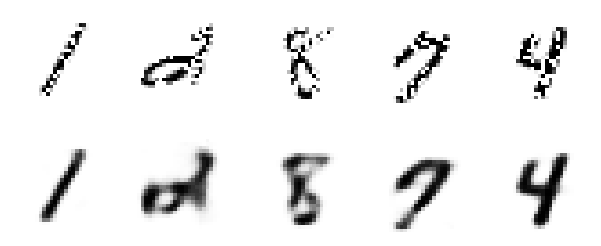

In [ ]:
dropout = tf.keras.layers.Dropout(0.3)
plot_reconstructions(dropout_ae, dropout(X_valid, training=True))

In [ ]:
dropout_ae.save('ae_denoise.keras')

###GAN